# Step 3 — Synthesize Transmission Lines for v1-imported Buses

Step 2 added 26 v1 substations / generators / BESS as isolated nodes. This notebook connects them to the transmission graph.

**Two passes:**
1. **Panay group** (9 v1 buses + 1 matched OSM bus, `sub_osm_4` Concepcion): no existing transmission to attach to, so build a 138 kV backbone via Minimum Spanning Tree over the 10 nodes in UTM. The MST gives a plausible tree topology; not necessarily the real NGCP grid.
2. **Non-Panay v1 buses** (17 across Cebu, Negros, Leyte, Bohol): for each, find the nearest existing transmission bus in the **same island** and add one spur line.

**Line attribute rules** (apply to every synthesised line):
- `voltage_kv = min(from.voltage_kv, to.voltage_kv)` — keeps a mixed-voltage edge at the lower side; Phase 2 will add explicit transformers.
- `is_submarine = (from.island != to.island)` — crossings of inter-island straits use XLPE impedance.
- `length_km = UTM distance / 1000`
- `is_synthetic = True`, `data_source = 'synthetic_v1'`, `cable_type` set accordingly.

**Output:** rows appended to [lines.csv](../backend/data/processed/lines.csv); summary CSV saved alongside.

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import geopandas as gpd
from shapely.geometry import Point
from scipy.sparse import csr_matrix
from scipy.sparse.csgraph import minimum_spanning_tree

PROC_DIR = Path('../backend/data/processed')
WGS = 'EPSG:4326'
UTM = 'EPSG:32651'

SPUR_MAX_KM = 15.0  # don't spur to a transmission node farther than this

OVERHEAD_IMPEDANCE = {
    60:  (0.18, 0.42, 0.45),
    69:  (0.15, 0.40, 0.50),
    138: (0.08, 0.40, 0.70),
    230: (0.05, 0.40, 0.90),
    350: (0.04, 0.30, 1.20),
    500: (0.03, 0.30, 1.50),
}
SUBMARINE_IMPEDANCE = (0.0754, 0.121, 0.645)

def nearest_v_class(v):
    return min(OVERHEAD_IMPEDANCE.keys(), key=lambda k: abs(k - v))

def impedance_for(voltage_kv, is_submarine):
    if is_submarine:
        return SUBMARINE_IMPEDANCE
    return OVERHEAD_IMPEDANCE[nearest_v_class(voltage_kv)]

In [2]:
buses = pd.read_csv(PROC_DIR / 'buses.csv')
lines = pd.read_csv(PROC_DIR / 'lines.csv')
print(f'Inputs: {len(buses)} buses, {len(lines)} lines')

v1_buses = buses[buses['data_source'] == 'v1_curated'].copy()
print(f'v1_curated buses to connect: {len(v1_buses)}')
print(f'  by island: {v1_buses["island"].value_counts().to_dict()}')

# Promote: also include sub_osm_4 (matched to Concepcion) into the Panay MST,
# because it is the only OSM-derived Panay transmission bus and the MST needs
# a hook into existing geometry.
panay_islands = {'Panay', 'Guimaras'}
panay_v1 = v1_buses[v1_buses['island'].isin(panay_islands)].copy()
concepcion = buses[buses['bus_id'] == 'sub_osm_4'].copy()
panay_group = pd.concat([panay_v1, concepcion], ignore_index=True)
print(f'\nPanay MST nodes (v1 + sub_osm_4): {len(panay_group)}')
print(panay_group[['bus_id', 'name', 'province', 'island', 'voltage_kv']].to_string(index=False))

Inputs: 2454 buses, 2432 lines
v1_curated buses to connect: 26
  by island: {'Panay': 8, 'Negros': 7, 'Cebu': 5, 'Leyte': 3, 'Bohol': 2, 'Guimaras': 1}

Panay MST nodes (v1 + sub_osm_4): 10
       bus_id                                  name province   island  voltage_kv
  v1_08bvista      Buena Vista substation, Guimaras Guimaras Guimaras       138.0
  v1_08bantap             Bantap substation, Iloilo   Iloilo    Panay        69.0
 v1_08barotac            Barotac substation, Iloilo   Iloilo    Panay       138.0
  v1_08dingle             Dingle substation, Iloilo   Iloilo    Panay       138.0
 v1_08iloilo1 Iloilo 1 main substation, Iloilo City   Iloilo    Panay       138.0
   v1_08nabas     Nabas wind farm substation, Aklan    Aklan    Panay       138.0
 v1_08panitan             Panitan substation, Capiz    Capiz    Panay       138.0
  v1_08snjose           San Jose substation, Iloilo   Iloilo    Panay       138.0
v1_08stbarbra      Santa Barbara substation, Iloilo   Iloilo    Panay   

## §1 — Panay MST backbone

In [3]:
# Project to UTM for metric distances
panay_g = gpd.GeoDataFrame(
    panay_group,
    geometry=gpd.points_from_xy(panay_group['lon'], panay_group['lat']),
    crs=WGS,
).to_crs(UTM).reset_index(drop=True)

coords = np.array([(g.x, g.y) for g in panay_g.geometry])
n = len(coords)
# Pairwise distance matrix (meters)
diff = coords[:, None, :] - coords[None, :, :]
dist = np.sqrt((diff ** 2).sum(-1))

mst = minimum_spanning_tree(csr_matrix(dist))
mst = mst.toarray()
edges = [(i, j, mst[i, j]) for i in range(n) for j in range(n) if mst[i, j] > 0]
print(f'MST edges over {n} nodes: {len(edges)} (expected {n-1})')
for i, j, d in edges:
    print(f'  {panay_g.iloc[i]["bus_id"]:<18} ↔ {panay_g.iloc[j]["bus_id"]:<18} {d/1000:.1f} km')

MST edges over 10 nodes: 9 (expected 9)
  v1_08bvista        ↔ v1_08iloilo1       7.3 km
  v1_08bantap        ↔ v1_08iloilo1       1.8 km
  v1_08bantap        ↔ v1_08stbarbra      12.0 km
  v1_08barotac       ↔ v1_08dingle        26.2 km
  v1_08barotac       ↔ sub_osm_4          32.3 km
  v1_08dingle        ↔ v1_08snjose        10.7 km
  v1_08nabas         ↔ v1_08panitan       83.8 km
  v1_08panitan       ↔ sub_osm_4          49.2 km
  v1_08snjose        ↔ v1_08stbarbra      18.2 km


In [4]:
panay_line_rows = []
for i, j, d_m in edges:
    a = panay_g.iloc[i]
    b = panay_g.iloc[j]
    voltage = min(a['voltage_kv'], b['voltage_kv'])
    is_sub = a['island'] != b['island']
    r, x, imax = impedance_for(voltage, is_sub)
    panay_line_rows.append({
        'line_id': f'line_synth_panay_{i:02d}_{j:02d}',
        'from_bus': a['bus_id'],
        'to_bus':   b['bus_id'],
        'voltage_kv': voltage,
        'length_km':  d_m / 1000,
        'r_ohm_per_km': r, 'x_ohm_per_km': x, 'max_i_ka': imax,
        'is_submarine': is_sub,
        'cable_type':   'submarine_xlpe' if is_sub else 'overhead',
        'is_synthetic': True,
        'data_source':  'synthetic_v1',
    })
panay_lines = pd.DataFrame(panay_line_rows)
print(f'Panay backbone lines: {len(panay_lines)}')
print(panay_lines[['from_bus', 'to_bus', 'voltage_kv', 'length_km', 'is_submarine']].to_string(index=False))

Panay backbone lines: 9
    from_bus        to_bus  voltage_kv  length_km  is_submarine
 v1_08bvista  v1_08iloilo1       138.0   7.305698          True
 v1_08bantap  v1_08iloilo1        69.0   1.769690         False
 v1_08bantap v1_08stbarbra        69.0  12.018589         False
v1_08barotac   v1_08dingle       138.0  26.170494         False
v1_08barotac     sub_osm_4       138.0  32.289559         False
 v1_08dingle   v1_08snjose       138.0  10.734139         False
  v1_08nabas  v1_08panitan       138.0  83.842754         False
v1_08panitan     sub_osm_4       138.0  49.229829         False
 v1_08snjose v1_08stbarbra       138.0  18.232350         False


## §2 — Non-Panay spurs

For each non-Panay v1 bus, find the nearest existing transmission bus in the same island. Existing transmission = anything not synthetic and not distribution: substations (osm and v1), towers (osm-snapped). Cap the spur distance at 15 km — anything farther is suspect.

In [5]:
non_panay_v1 = v1_buses[~v1_buses['island'].isin(panay_islands)].copy()
print(f'Non-Panay v1 buses needing spurs: {len(non_panay_v1)}')
print(non_panay_v1[['bus_id', 'name', 'province', 'island', 'voltage_kv']].to_string(index=False))

# Transmission-eligible existing buses: substation/tower/substation_synth, NOT v1 (we just added them)
existing_tx_mask = (
    buses['bus_type'].isin(['substation', 'tower', 'substation_synth'])
    & (buses['data_source'] != 'v1_curated')
)
existing_tx = buses[existing_tx_mask].copy()
print(f'\nExisting transmission-eligible buses available for spurs: {len(existing_tx)}')

Non-Panay v1 buses needing spurs: 17
         bus_id                                                           name          province island  voltage_kv
   v1_07corella                                      Corella substation, Bohol             Bohol  Bohol       138.0
     v1_07tapal                                        Tapal substation, Bohol             Bohol  Bohol       138.0
      v1_05cebu                                Cebu main substation, Cebu City              Cebu   Cebu       138.0
 v1_05daanbntay                                 Daan Bantayan substation, Cebu              Cebu   Cebu       230.0
v1_05daanlunsod                                  Daan Lungsod substation, Cebu              Cebu   Cebu       230.0
      v1_05naga                                          Naga substation, Cebu              Cebu   Cebu       138.0
    v1_05therma                    Therma Visayas power plant substation, Cebu              Cebu   Cebu       138.0
  v1_04babatngn                    

In [6]:
# Project both sets to UTM and do per-island nearest joins
non_panay_g = gpd.GeoDataFrame(
    non_panay_v1,
    geometry=gpd.points_from_xy(non_panay_v1['lon'], non_panay_v1['lat']),
    crs=WGS,
).to_crs(UTM)
existing_g = gpd.GeoDataFrame(
    existing_tx,
    geometry=gpd.points_from_xy(existing_tx['lon'], existing_tx['lat']),
    crs=WGS,
).to_crs(UTM)

spur_rows = []
no_match = []
for _, v in non_panay_g.iterrows():
    candidates = existing_g[existing_g['island'] == v['island']]
    if len(candidates) == 0:
        no_match.append((v['bus_id'], v['island'], 'no candidates in island'))
        continue
    dists = candidates.geometry.distance(v.geometry)
    nearest_idx = dists.idxmin()
    d_m = dists.loc[nearest_idx]
    if d_m > SPUR_MAX_KM * 1000:
        no_match.append((v['bus_id'], v['island'], f'nearest {d_m/1000:.1f} km > {SPUR_MAX_KM} km cap'))
        continue
    nearest = candidates.loc[nearest_idx]
    voltage = min(v['voltage_kv'], nearest['voltage_kv'])
    r, x, imax = impedance_for(voltage, is_submarine=False)
    spur_rows.append({
        'line_id': f'line_synth_spur_{len(spur_rows):03d}',
        'from_bus': v['bus_id'],
        'to_bus':   nearest['bus_id'],
        'voltage_kv': voltage,
        'length_km':  d_m / 1000,
        'r_ohm_per_km': r, 'x_ohm_per_km': x, 'max_i_ka': imax,
        'is_submarine': False,
        'cable_type':   'overhead',
        'is_synthetic': True,
        'data_source':  'synthetic_v1',
    })

spur_lines = pd.DataFrame(spur_rows)
print(f'Spurs generated: {len(spur_lines)}')
print(f'Unmatched: {len(no_match)}')
if no_match:
    for r in no_match:
        print(f'  {r[0]} (island={r[1]}): {r[2]}')
print()
print('Spur details:')
print(spur_lines[['from_bus', 'to_bus', 'voltage_kv', 'length_km']].to_string(index=False))

Spurs generated: 15
Unmatched: 2
  v1_06kabankalan (island=Negros): nearest 33.2 km > 15.0 km cap
  v1_06kbanbess (island=Negros): nearest 33.2 km > 15.0 km cap

Spur details:
       from_bus                              to_bus  voltage_kv  length_km
   v1_07corella  sub_corella_substation_boheco_i_18       138.0   6.502549
     v1_07tapal              sub_ubay_substation_54       138.0   3.933207
      v1_05cebu                           sub_osm_2       138.0   1.489175
 v1_05daanbntay sub_medellin_load_end_substation_23       138.0   5.327915
v1_05daanlunsod sub_medellin_load_end_substation_23       138.0   5.327915
      v1_05naga             sub_colon_substation_67       138.0   3.535679
    v1_05therma                          sub_osm_83       138.0   3.284203
  v1_04babatngn         sub_babatngon_substation_20       138.0   7.321270
   v1_04kananga                          tower_0011       230.0   5.997504
   v1_04tongona                          tower_0040       138.0   0.122280

## §3 — Combine, validate, save

In [7]:
new_lines = pd.concat([panay_lines, spur_lines], ignore_index=True)
print(f'New synthesized lines: {len(new_lines)} (Panay MST: {len(panay_lines)}, spurs: {len(spur_lines)})')

# Schema check
valid_buses = set(buses['bus_id'])
assert new_lines['from_bus'].isin(valid_buses).all(), 'from_bus orphan'
assert new_lines['to_bus'].isin(valid_buses).all(),   'to_bus orphan'
assert (new_lines['from_bus'] != new_lines['to_bus']).all(), 'self-loops detected'
assert new_lines['line_id'].is_unique

# Match lines.csv schema (drop any extra columns lines.csv doesn't have)
schema_cols = lines.columns.tolist()
new_lines_aligned = new_lines.reindex(columns=schema_cols, fill_value=np.nan)
lines_out = pd.concat([lines, new_lines_aligned], ignore_index=True)
assert lines_out['line_id'].is_unique

lines_out.to_csv(PROC_DIR / 'lines.csv', index=False)
print(f'\nWrote {PROC_DIR / "lines.csv"} ({len(lines_out)} rows; +{len(new_lines)} new)')

new_lines.to_csv(PROC_DIR / 'synth_v1_lines.csv', index=False)
print(f'Wrote {PROC_DIR / "synth_v1_lines.csv"} ({len(new_lines)} rows; for traceability)')

New synthesized lines: 24 (Panay MST: 9, spurs: 15)

Wrote ../backend/data/processed/lines.csv (2456 rows; +24 new)
Wrote ../backend/data/processed/synth_v1_lines.csv (24 rows; for traceability)


In [8]:
# Connectivity check on transmission-only subgraph (exclude synth distribution)
import networkx as nx
tx_lines = lines_out[~lines_out['voltage_kv'].between(10, 50)]  # exclude 13.8 kV distribution
tx_buses_in_lines = set(tx_lines['from_bus']) | set(tx_lines['to_bus'])
G = nx.Graph()
G.add_nodes_from(tx_buses_in_lines)
G.add_edges_from(zip(tx_lines['from_bus'], tx_lines['to_bus']))
ncc = nx.number_connected_components(G)
sizes = sorted([len(c) for c in nx.connected_components(G)], reverse=True)
print(f'Transmission components: {ncc}')
print(f'Top 10 sizes: {sizes[:10]}')
print(f'Isolated (size 1): {sizes.count(1)}')

# Per-island
buses_idx = buses.set_index('bus_id')
print('\nPer-island transmission components:')
for island in sorted(buses['island'].dropna().unique()):
    island_buses = set(buses[buses['island'] == island]['bus_id']) & tx_buses_in_lines
    if not island_buses:
        print(f'  {island:12s} (no transmission buses)')
        continue
    sub = G.subgraph(island_buses)
    island_cc = nx.number_connected_components(sub)
    print(f'  {island:12s} buses={len(island_buses):4d}  components={island_cc}')

Transmission components: 18
Top 10 sizes: [90, 14, 11, 7, 6, 5, 4, 3, 3, 2]
Isolated (size 1): 0

Per-island transmission components:
  Biliran      (no transmission buses)
  Bohol        buses=  12  components=1
  Cebu         buses=  48  components=4
  Guimaras     buses=   1  components=1
  Leyte        buses=  35  components=4
  Negros       buses=  32  components=5
  Panay        buses=  10  components=1
  Samar        buses=  23  components=9
  Siquijor     (no transmission buses)


Text(103.84722222222221, 0.5, 'Latitude')

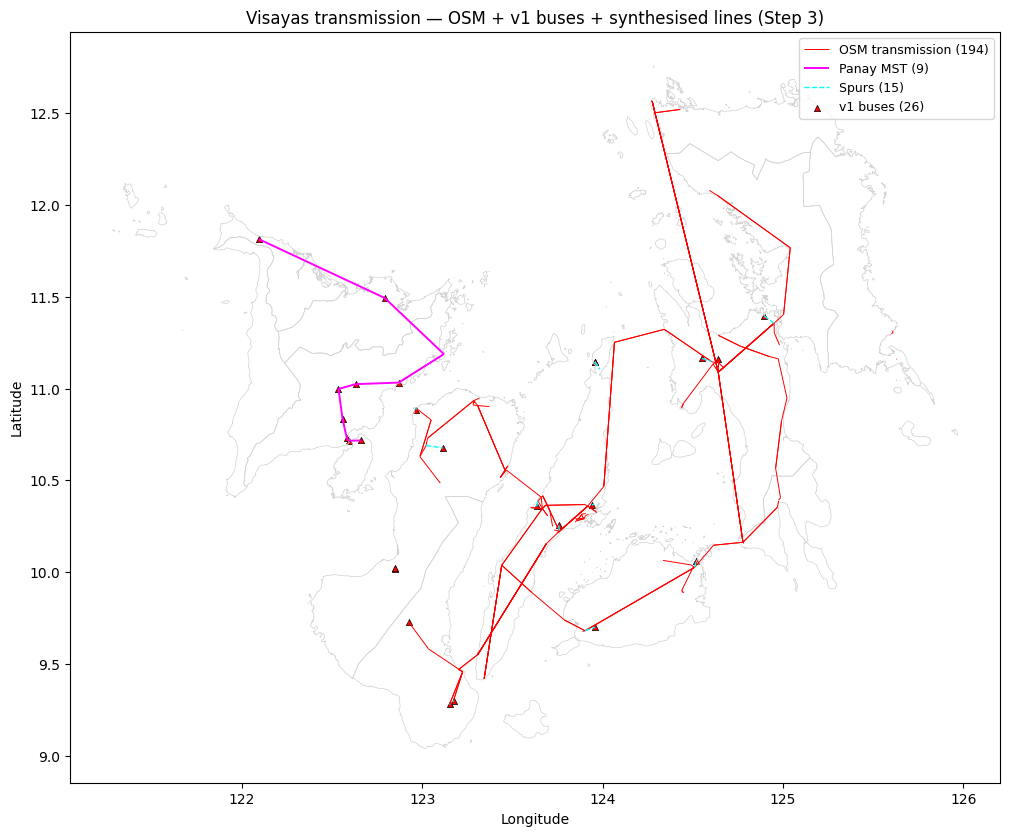

In [9]:
# Visual smoke test
import matplotlib.pyplot as plt
from shapely.geometry import LineString

provinces = gpd.read_file('../backend/data/boundaries/psgc_provinces.geojson')
bus_loc = buses.set_index('bus_id')[['lat', 'lon']]

def to_geom(row):
    a = bus_loc.loc[row['from_bus']]
    b = bus_loc.loc[row['to_bus']]
    return LineString([(a['lon'], a['lat']), (b['lon'], b['lat'])])

new_lines_g = gpd.GeoDataFrame(new_lines.copy(),
                                geometry=new_lines.apply(to_geom, axis=1), crs=WGS)
osm_tx = lines[~lines['voltage_kv'].between(10, 50)]
osm_tx_g = gpd.GeoDataFrame(osm_tx.copy(),
                             geometry=osm_tx.apply(to_geom, axis=1), crs=WGS)

fig, ax = plt.subplots(figsize=(12, 10))
provinces.boundary.plot(ax=ax, color='lightgrey', linewidth=0.5)
osm_tx_g.plot(ax=ax, color='red', linewidth=0.7, label=f'OSM transmission ({len(osm_tx_g)})')
panay_g_line = new_lines_g[new_lines_g['line_id'].str.startswith('line_synth_panay')]
spurs_g     = new_lines_g[new_lines_g['line_id'].str.startswith('line_synth_spur')]
if len(panay_g_line):
    panay_g_line.plot(ax=ax, color='magenta', linewidth=1.4, label=f'Panay MST ({len(panay_g_line)})')
if len(spurs_g):
    spurs_g.plot(ax=ax, color='cyan', linewidth=1.0, linestyle='--', label=f'Spurs ({len(spurs_g)})')

# Plot v1 buses as triangles
v1_g_buses = gpd.GeoDataFrame(
    v1_buses, geometry=gpd.points_from_xy(v1_buses['lon'], v1_buses['lat']), crs=WGS)
v1_g_buses.plot(ax=ax, color='red', marker='^', markersize=20,
                 label=f'v1 buses ({len(v1_g_buses)})', edgecolor='black', linewidth=0.5)

ax.legend(loc='upper right', fontsize=9)
ax.set_title('Visayas transmission — OSM + v1 buses + synthesised lines (Step 3)')
ax.set_xlabel('Longitude'); ax.set_ylabel('Latitude')